# REPORT

# 1. DATA RETRIEVAL 

In [27]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns

sns.set()

import datetime as dt


import warnings 
warnings.filterwarnings('ignore')

In [28]:
df = pd.read_csv('/Users/macbook/Downloads/Walmart.csv')
print('Data downloaded and read into a dataframe!')

df.head()

Data downloaded and read into a dataframe!


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [29]:
df.head(3)

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


# 2. DATA WRANGLING

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [32]:
#Chuyển đổi chữ trong cột thành chữ thường
df.columns = [col.lower() for col in df.columns ]

In [33]:
df.columns

Index(['store', 'date', 'weekly_sales', 'holiday_flag', 'temperature',
       'fuel_price', 'cpi', 'unemployment'],
      dtype='object')

In [34]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   store         6435 non-null   int64  
 1   date          6435 non-null   object 
 2   weekly_sales  6435 non-null   float64
 3   holiday_flag  6435 non-null   int64  
 4   temperature   6435 non-null   float64
 5   fuel_price    6435 non-null   float64
 6   cpi           6435 non-null   float64
 7   unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [35]:
#Chuyển thời gian từ định dạng object sang thành datetime
from datetime import datetime

df['date'] = pd.to_datetime(df['date'], format='%d-%m-%Y')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   store         6435 non-null   int64         
 1   date          6435 non-null   datetime64[ns]
 2   weekly_sales  6435 non-null   float64       
 3   holiday_flag  6435 non-null   int64         
 4   temperature   6435 non-null   float64       
 5   fuel_price    6435 non-null   float64       
 6   cpi           6435 non-null   float64       
 7   unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


In [36]:
df['date']

0      2010-02-05
1      2010-02-12
2      2010-02-19
3      2010-02-26
4      2010-03-05
          ...    
6430   2012-09-28
6431   2012-10-05
6432   2012-10-12
6433   2012-10-19
6434   2012-10-26
Name: date, Length: 6435, dtype: datetime64[ns]

In [37]:
df[df.duplicated()]

,store,date,weekly_sales,holiday_flag,temperature,fuel_price,cpi,unemployment


=> data không có biến nào trùng lặp

In [38]:
def find_outlier_rows(df, col, level='both'):
    iqr = df[col].quantile(0.75) - df[col].quantile(0.25)

    lower_bound = df[col].quantile(0.25) - 1.5 * iqr
    upper_bound = df[col].quantile(0.75) + 1.5 * iqr
    if level == 'lower':
        return df[df[col] < lower_bound]
    elif level == 'upper':
        return df[df[col] > upper_bound]
    else:
        return df[(df[col] > upper_bound) | (df[col] < lower_bound)]
    
def outliers(df):
    columns = df.columns

    outlier_cols = [col for col in columns if len(find_outlier_rows(df, col)) != 0]

    outliers_df = pd.DataFrame(columns=['outlier_counts', 'outlier_percent'])

    for col in outlier_cols:
        outlier_count = len(find_outlier_rows(df, col))
        all_entries = len(df[col])
        outlier_percent = round(outlier_count * 100 / all_entries, 2)

        outliers_df.loc[col] = [outlier_count, outlier_percent]

    return outliers_df

In [39]:
outliers(df).sort_values('outlier_counts', ascending=False)

,outlier_counts,outlier_percent
unemployment,481.0,7.47
holiday_flag,450.0,6.99
weekly_sales,34.0,0.53
temperature,3.0,0.05


In [40]:
find_outlier_rows(df, 'temperature')['temperature'].describe()

count    3.000000
mean     3.236667
std      4.600004
min     -2.060000
25%      1.740000
50%      5.540000
75%      5.885000
max      6.230000
Name: temperature, dtype: float64

# 3. DATA STATISTICAL DESCRIPTION

In [41]:
find_outlier_rows(df, 'weekly_sales')

,store,date,weekly_sales,holiday_flag,temperature,fuel_price,cpi,unemployment
189,2,2010-12-24,3436007.68,0,49.97,2.886,211.064660,8.163
241,2,2011-12-23,3224369.80,0,46.66,3.112,218.999550,7.441
471,4,2010-11-26,2789469.45,1,48.08,2.752,126.669267,7.127
474,4,2010-12-17,2740057.14,0,46.57,2.884,126.879484,7.127
475,4,2010-12-24,3526713.39,0,43.21,2.887,126.983581,7.127
523,4,2011-11-25,3004702.33,1,47.96,3.225,129.836400,5.143
526,4,2011-12-16,2771397.17,0,36.44,3.149,129.898065,5.143
527,4,2011-12-23,3676388.98,0,35.92,3.103,129.984548,5.143
761,6,2010-12-24,2727575.18,0,55.07,2.886,212.916508,7.007
1329,10,2010-11-26,2939946.38,1,55.33,3.162,126.669267,9.003


In [42]:
df['employment'] = 100 - df['unemployment']

df['year']= df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day

def get_season(month):
    if month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    elif month in [9, 10, 11]:
        return 'fall'
    else:
        return 'winter'

df['season'] = df['month'].apply(get_season)

df.head(3)

,store,date,weekly_sales,holiday_flag,temperature,fuel_price,cpi,unemployment,employment,year,month,day,season
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,91.894,2010,2,5,winter
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,91.894,2010,2,12,winter
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,91.894,2010,2,19,winter


In [43]:
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month

def get_season(month):
    if month in [3, 4, 5]:
        return 'spring'
    elif month in [6, 7, 8]:
        return 'summer'
    elif month in [9, 10, 11]:
        return 'fall'
    else:
        return 'winter'

df['Season'] = df['month'].apply(get_season)

df.head()


,store,date,weekly_sales,holiday_flag,temperature,fuel_price,cpi,unemployment,employment,year,month,day,season,Season
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,91.894,2010,2,5,winter,winter
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,91.894,2010,2,12,winter,winter
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,91.894,2010,2,19,winter,winter
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,91.894,2010,2,26,winter,winter
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,91.894,2010,3,5,spring,spring


Tạo thêm 1 cột mùa và tháng nhằm gộp các tuần lại theo mùa

In [44]:
rev = df.groupby('Season')[['weekly_sales','temperature','holiday_flag','fuel_price','cpi']].sum().reset_index()
rev

,Season,weekly_sales,temperature,holiday_flag,fuel_price,cpi
0,fall,1.576562e+09,96343.09,225,5114.122,263107.018079
1,spring,1.796771e+09,100792.28,0,6134.814,300719.079224
2,summer,1.885721e+09,140610.66,0,6083.403,309365.397357
3,winter,1.478165e+09,52625.41,225,4280.296,230915.469757


Tính tổng sơ bộ của các biến, cho thấy:
- Nhìn chung số ngày nghỉ thường rơi nhiều vào mùa thu và mùa đông: 225 số ngày nghỉ
- Vào các ngày không phải ngày nghỉ của mùa xuân và mùa hè, biến "weekly_sales" và biến "cpi" có sự chênh lệch tương đối rõ ràng so với 2 mùa còn lại với các chỉ số lần lượt là [1.796771e+09 & 1.885721e+09] và [300719.079224 & 309365.397357] tương ứng.

-> Điều này thể hiện rằng vào mùa xuân và mùa hè, mọi người có xu hướng chi tiêu nhiều hơn khi họ phải tiêu tốn 1 khoản chi phí mỗi tuần dành cho việc đi lại và chi tiêu hàng tuần. Ngược lại, vào các mùa thu và đông, số ngày nghỉ thường tập trung vào 2 mùa này vì yếu tố thời tiết khắc nghiệt, nhiệt độ bình quân thấp hơn bình thường khiến cho đa số người tiêu dùng có xu hướng ở nhà của họ nhiều hơn là ra ngoài đường và chi tiêu, mặt khác người Mỹ thường dành kỳ nghỉ của họ cho gia đình. Điều này cũng thể hiện rõ ràng thông qua giá trị của 2 biến "weekly_sales" và "cpi" có thông số thấp hơn hẳn so với 2 mùa còn lại.

In [45]:
rev_stats = df.groupby('Season')[['weekly_sales','temperature','holiday_flag','cpi']].describe().reset_index()

print(rev_stats)

   Season weekly_sales                                                       \
                 count          mean            std        min          25%   
0    fall       1530.0  1.030432e+06  552072.983929  213538.32  537909.2000   
1  spring       1755.0  1.023801e+06  536720.854048  232769.09  540959.2150   
2  summer       1800.0  1.047623e+06  540498.643595  224031.19  576814.4400   
3  winter       1350.0  1.094937e+06  637345.953654  209986.25  560211.6125   

                                        temperature  ... holiday_flag       \
          50%           75%         max       count  ...          75%  max   
0  947683.745  1.391096e+06  3004702.33      1530.0  ...          0.0  1.0   
1  951588.370  1.388654e+06  2565259.92      1755.0  ...          0.0  0.0   
2  970551.160  1.431762e+06  2363601.47      1800.0  ...          0.0  0.0   
3  993276.360  1.497173e+06  3818686.45      1350.0  ...          0.0  1.0   

      cpi                                               

In [46]:
rev.dropna()

print(df.isna().sum())  
print((df == float('inf')).sum())

df_cleaned = df.replace([float('inf'), float('-inf')], pd.NA).dropna()

df = df.replace([float('inf'), float('-inf')], pd.NA)

store           0
date            0
weekly_sales    0
holiday_flag    0
temperature     0
fuel_price      0
cpi             0
unemployment    0
employment      0
year            0
month           0
day             0
season          0
Season          0
dtype: int64
store           0
date            0
weekly_sales    0
holiday_flag    0
temperature     0
fuel_price      0
cpi             0
unemployment    0
employment      0
year            0
month           0
day             0
season          0
Season          0
dtype: int64


In [47]:
df.columns()

TypeError: 'Index' object is not callable

In [ ]:
from linearmodels.panel import PanelOLS

df = df.set_index(['high', 'low'])

y = df['open']
X = df[['high', 'low', 'volumn']]

X = X.assign(constant=1)

model = PanelOLS(y, X, entity_effects=True)
fe_results = model.fit()

print(fe_results.summary)

KeyError: "None of ['high', 'low'] are in the columns"

# 4. OLS model estiomation

In [ ]:
import statsmodels.api as sm

season_dummies = pd.get_dummies(df['Season'], prefix='Season')
weekly_sales_dummies = pd.get_dummies(df['weekly_sales'], prefix='weekly_sales')

X = pd.concat([df[['temperature', 'fuel_price', 'cpi']], season_dummies, holiday_dummies], axis=1)
y = df['cpi']

X = sm.add_constant(X)

model = sm.OLS(y.astype(float), X.astype(float)).fit()

print(model.summary())

NameError: name 'holiday_dummies' is not defined

# 5. TIME SERIES ESTIMATION METHOD WITH VISUALIZATION

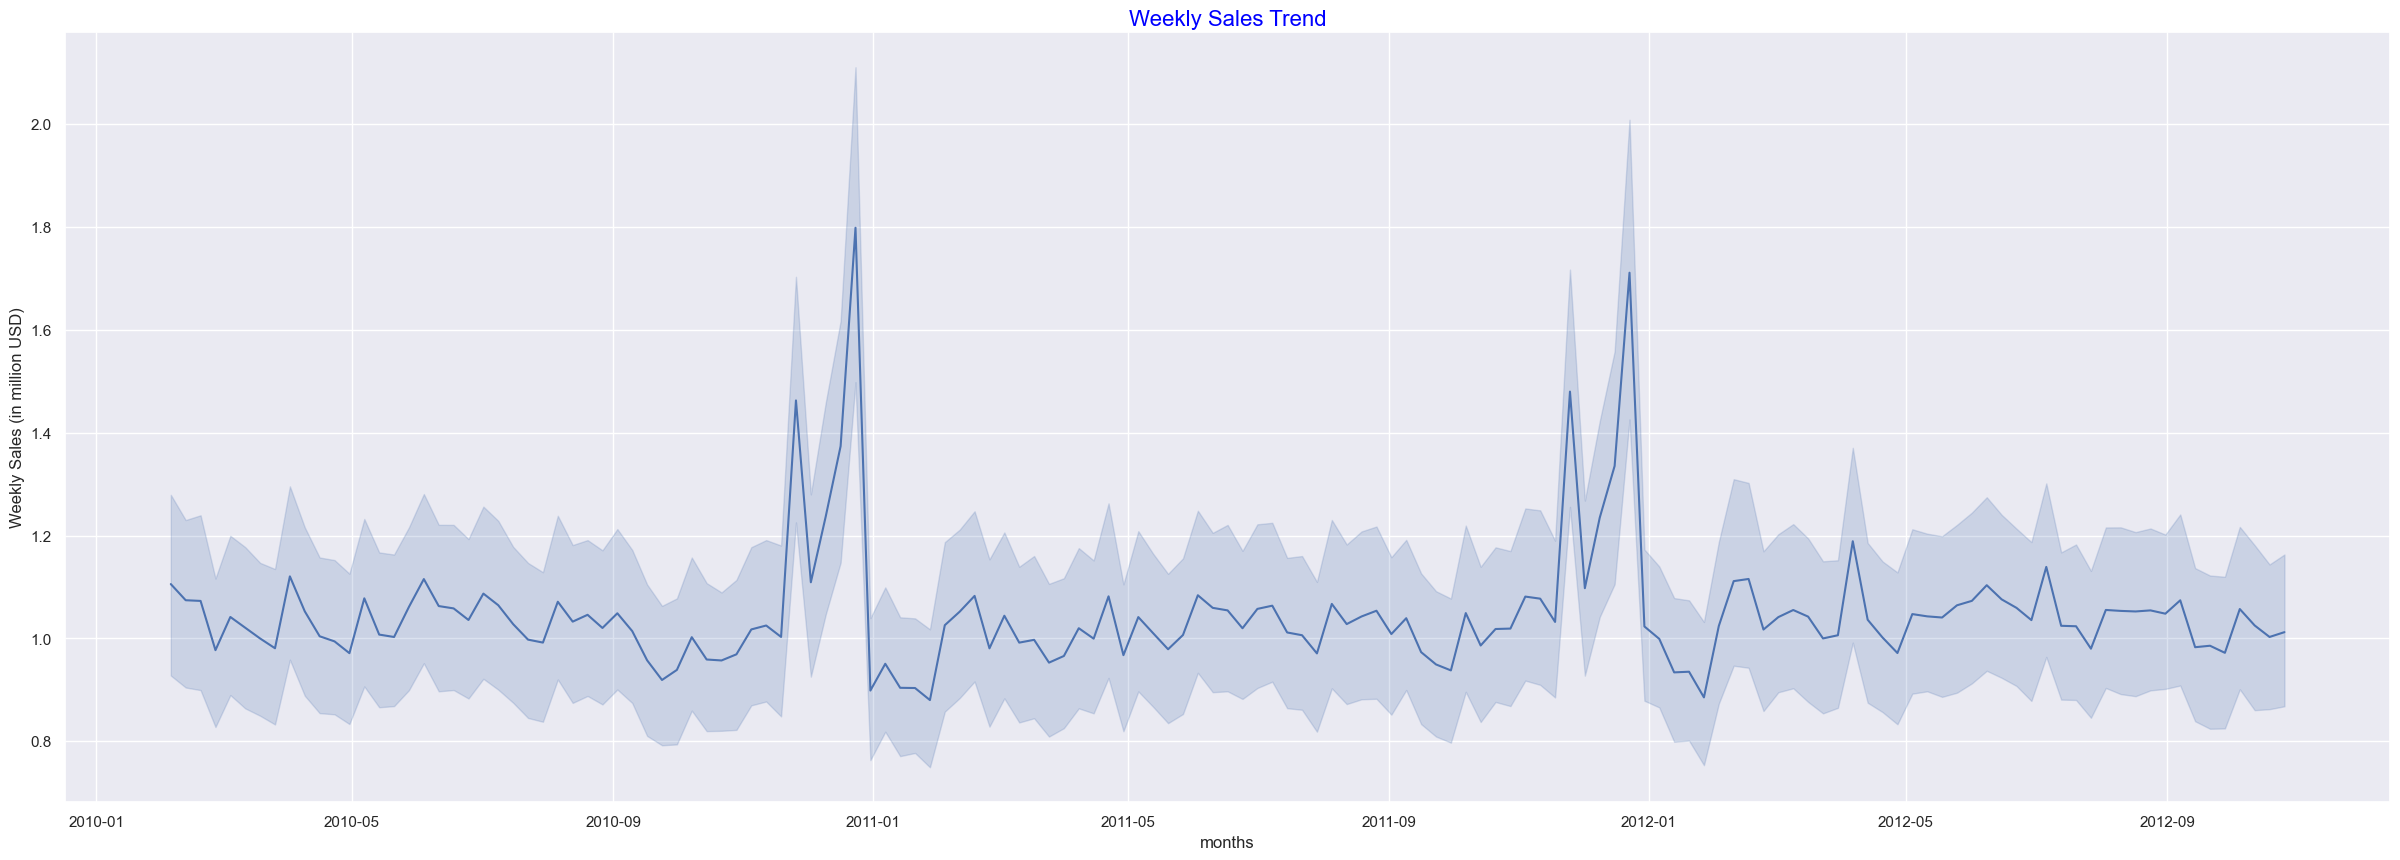

In [ ]:
fig, ax = plt.subplots(figsize=(30, 10))
sns.lineplot(x=df.date, y=(df.weekly_sales/1e6))
plt.xlabel('months')
plt.ylabel('Weekly Sales (in million USD)')
plt.title('Weekly Sales Trend',fontdict={'fontsize': 16, 'color':'blue'}, pad=5)

annot = ax.annotate("", xy=(0,0), xytext=(20,20),textcoords="offset points",
                    bbox=dict(boxstyle="round", fc="w"),
                    arrowprops=dict(arrowstyle="->"))
annot.set_visible(False)

plt.show()

SEASONALITY TRENDS

In [ ]:
df

,store,date,weekly_sales,holiday_flag,temperature,fuel_price,cpi,unemployment,employment,year,month,day,season,Season
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,91.894,2010,2,5,winter,winter
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,91.894,2010,2,12,winter,winter
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,91.894,2010,2,19,winter,winter
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,91.894,2010,2,26,winter,winter
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,91.894,2010,3,5,spring,spring
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6430,45,2012-09-28,713173.95,0,64.88,3.997,192.013558,8.684,91.316,2012,9,28,fall,fall
6431,45,2012-10-05,733455.07,0,64.89,3.985,192.170412,8.667,91.333,2012,10,5,fall,fall
6432,45,2012-10-12,734464.36,0,54.47,4.000,192.327265,8.667,91.333,2012,10,12,fall,fall
6433,45,2012-10-19,718125.53,0,56.47,3.969,192.330854,8.667,91.333,2012,10,19,fall,fall


In [ ]:
pivot_table = df.pivot_table(index='year', columns='season', values='weekly_sales')
pivot_table

season,fall,spring,summer,winter
year,,,,
2010,1.020997e+06,1.025715e+06,1.046951e+06,1.182947e+06
2011,1.050037e+06,1.004327e+06,1.039802e+06,1.090792e+06
2012,1.013909e+06,1.041362e+06,1.055509e+06,1.002661e+06


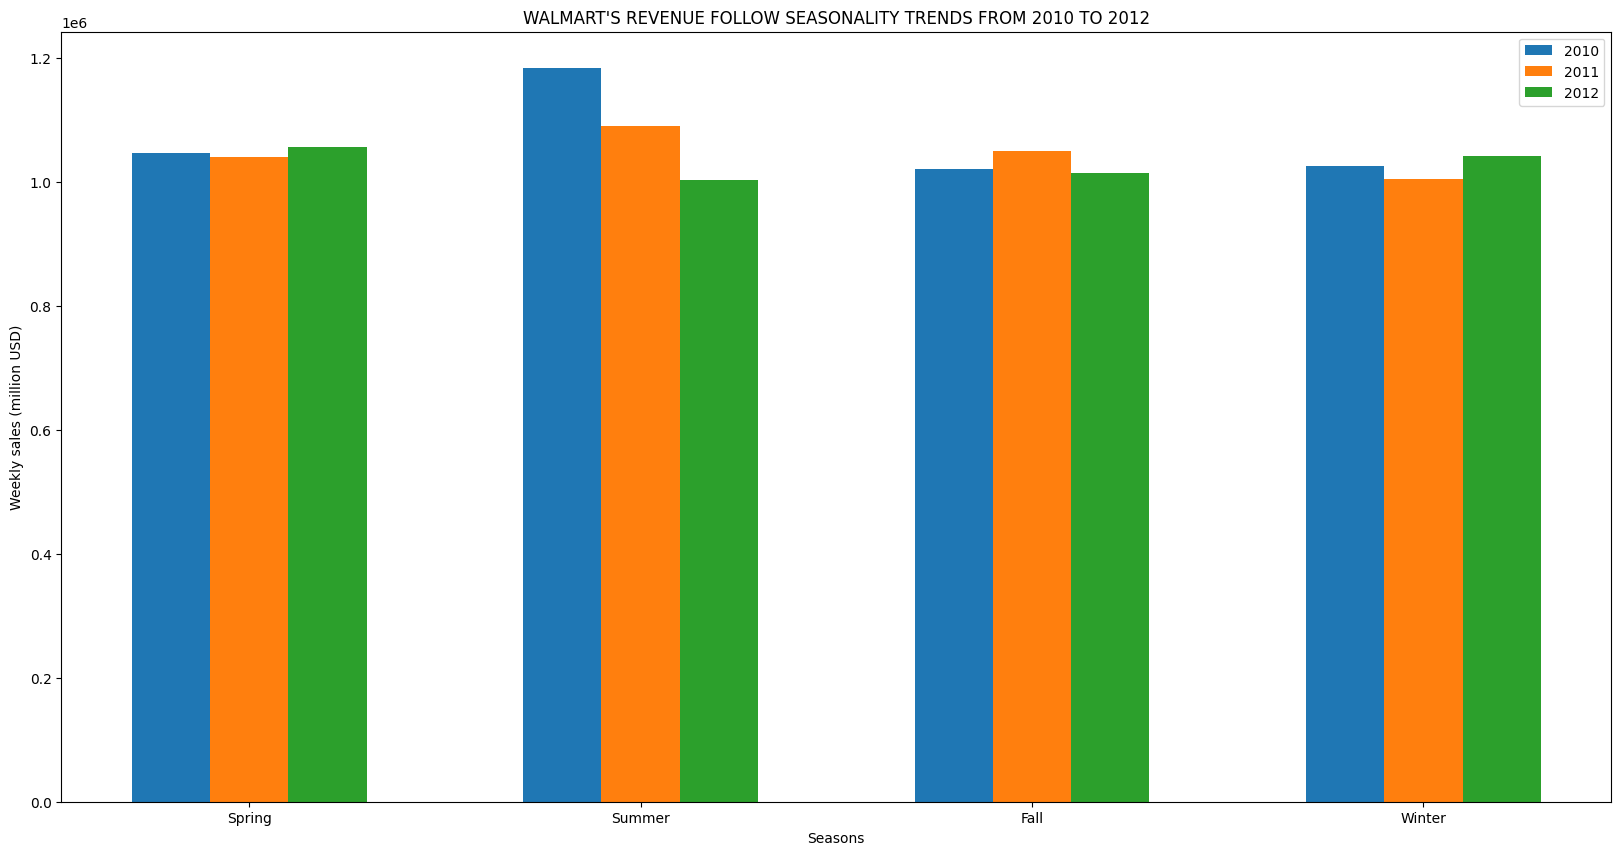

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

sales_data = {
    2010: [1.046951e+06, 1.182947e+06, 1.020997e+06, 1.025715e+06],
    2011: [1.039802e+06, 1.090792e+06, 1.050037e+06, 1.004327e+06],
    2012: [1.055509e+06, 1.002661e+06, 1.013909e+06, 1.041362e+06]
}

#data dựa trên pivot_table ở trên

seasons = ['Spring', 'Summer', 'Fall', 'Winter']

years = list(sales_data.keys())

fig, ax = plt.subplots(figsize=(20, 10))

x = np.arange(len(seasons)) 
width = 0.2

for i, year in enumerate(years):
    ax.bar(x + i*width, sales_data[year], width, label=str(year))

ax.set_xticks(x + (len(years)-1)*width/2)
ax.set_xticklabels(seasons)

ax.set_xlabel('Seasons')
ax.set_ylabel('Weekly sales (million USD)')
ax.set_title("WALMART'S REVENUE FOLLOW SEASONALITY TRENDS FROM 2010 TO 2012")
ax.legend()

plt.show()


In [ ]:
df.columns()

TypeError: 'Index' object is not callable